# Predição do preço do ouro com CNN 1D

**Horizontes:** 5, 15 e 30 dias &nbsp;|&nbsp; **Dataset:** `final_gold_data.csv` (metais preciosos desde 2000, com manchetes)

Este notebook treina uma rede convolucional 1D para prever o preço do ouro e **visualiza o desempenho** em conjuntos separados de treino, validação e teste.

### Ideia central
Não prevemos o **preço** (foi de ~US\$280 em 2000 a ~US\$3.000 em 2025 — um modelo treinado em preço nunca veria os níveis do teste). Prevemos o **log-retorno acumulado** `log(P[t+h]/P[t])`, que é quase estacionário, e reconstruímos o preço com `P·exp(r)`.

### Roteiro
1. Setup e carregamento
2. Engenharia de features (relativas) e alvos
3. Janela deslizante + split temporal sem vazamento
4. Escalonamento robusto a outliers
5. Modelo CNN (3 cabeças)
6. Treino — **curvas de aprendizado**
7. Avaliação treino/val/teste vs. baseline
8. **Gráficos de desempenho** (previsto×real, dispersão, erro por ano, resíduos)

## 1. Setup e carregamento

Ajuste `CSV_PATH` para o caminho do seu arquivo. As constantes controlam a janela (`LOOKBACK`), os horizontes e o `GAP` entre os conjuntos (evita que janelas vizinhas vazem informação do futuro).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10}
)
DARK, RED, BLUE = "#1a1a2e", "#e94560", "#0f3460"

CSV_PATH = "../../data/processed/final_gold_data.csv"  # <-- ajuste aqui
LOOKBACK = 60  # tamanho da janela deslizante (dias)
HORIZONS = [5, 15, 30]  # horizontes de predição
GAP = max(HORIZONS)  # gap entre splits (anti-vazamento)
print("TensorFlow", tf.__version__)

I0000 00:00:1781625680.794577     555 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781625708.096919     555 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781625720.942544     555 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0


In [2]:
def load_data(csv_path):
    df = pd.read_csv(csv_path, sep=None, engine="python")  # auto-detecta , ou ;
    df.columns = [c.strip().lower() for c in df.columns]
    date_col = next((c for c in df.columns if "date" in c or "time" in c), None)
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    df = df.rename(columns={date_col: "date"})
    cands = ["close", "price", "gold", "adj close", "adj_close", "value"]
    price_col = next(
        (c for c in df.columns for k in cands if k in c and df[c].dtype != object), None
    )
    df = df.rename(columns={price_col: "close"})
    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df = df.dropna(subset=["close"]).reset_index(drop=True)
    return df


df_raw = load_data(CSV_PATH)
print(
    f"{len(df_raw)} pregões | {df_raw['date'].min().date()} -> {df_raw['date'].max().date()}"
)
df_raw[["date", "close"]].head()

6177 pregões | 2000-08-30 -> 2025-04-14


,date,close
0,2000-08-30,273.9
1,2000-08-31,278.3
2,2000-09-01,277.0
3,2000-09-05,275.8
4,2000-09-06,274.2


### Série histórica completa
O salto de nível ao longo de 25 anos é exatamente o motivo de prevermos retornos, não preço.

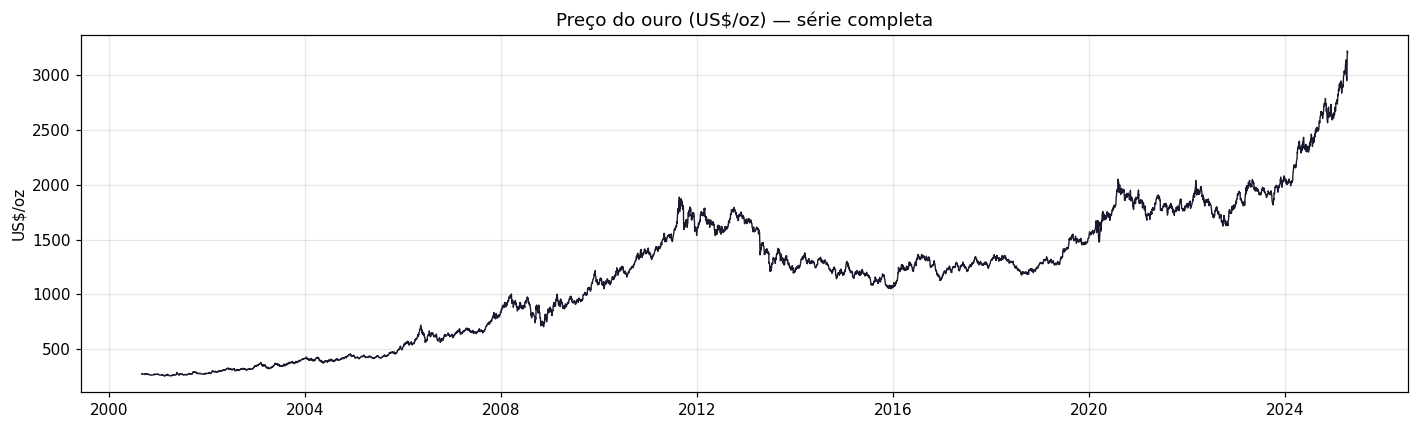

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_raw["date"], df_raw["close"], color=DARK, lw=0.9)
ax.set_title("Preço do ouro (US$/oz) — série completa")
ax.set_ylabel("US$/oz")
plt.tight_layout()
plt.show()

## 2. Engenharia de features e alvos

Todas as features são **relativas** (retornos, razões, osciladores) — nunca preço bruto — para generalizar entre níveis. Inclui um índice de "medo" extraído das manchetes por léxico, já que o ouro reage a estresse geopolítico.

In [4]:
def build_features(df):
    out = df.copy()
    c = out["close"]
    out["log_ret_1"] = np.log(c / c.shift(1))
    out["log_ret_5"] = np.log(c / c.shift(5))
    out["log_ret_21"] = np.log(c / c.shift(21))
    out["vol_5"] = out["log_ret_1"].rolling(5).std()
    out["vol_21"] = out["log_ret_1"].rolling(21).std()
    out["vol_ratio"] = out["vol_5"] / (out["vol_21"] + 1e-9)  # >1 => estresse
    ma20, ma50 = c.rolling(20).mean(), c.rolling(50).mean()
    out["dist_ma20"] = c / ma20 - 1
    out["dist_ma50"] = c / ma50 - 1
    out["ma_cross"] = ma20 / ma50 - 1
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    out["rsi"] = ((100 - 100 / (1 + gain / (loss + 1e-9))) - 50) / 50
    ema12, ema26 = (
        c.ewm(span=12, adjust=False).mean(),
        c.ewm(span=26, adjust=False).mean(),
    )
    macd = ema12 - ema26
    signal = macd.ewm(span=9, adjust=False).mean()
    out["macd_hist"] = (macd - signal) / c
    std20 = c.rolling(20).std()
    out["boll_b"] = (c - (ma20 - 2 * std20)) / (4 * std20 + 1e-9) - 0.5
    out["drawdown_252"] = c / c.rolling(252).max() - 1
    if {"high", "low", "open"}.issubset(out.columns):
        h, l, o = out["high"], out["low"], out["open"]
        out["hl_range"] = (h - l) / c
        out["close_pos"] = (c - l) / (h - l + 1e-9) - 0.5
        out["gap_open"] = np.log(o / c.shift(1))
    if "headlines" in df.columns:
        fear = (
            "crisis|crash|war|recession|inflation|default|collapse|panic|fear|"
            "conflict|sanction|bankrupt|plunge|turmoil|slump|selloff|attack|"
            "invasion|pandemic|virus"
        )
        txt = df["headlines"].fillna("").str.lower()
        out["fear_ratio"] = txt.str.count(fear) / (txt.str.count("/") + 1)
        out["fear_ma5"] = out["fear_ratio"].rolling(5).mean()
    return out


def build_targets(df):
    c = df["close"]
    for h in HORIZONS:
        df[f"y_{h}"] = np.log(c.shift(-h) / c)
    return df


df = build_targets(build_features(df_raw))
feature_cols = [
    c
    for c in df.columns
    if c not in {"date", "close", "open", "high", "low"}
    and not c.startswith("y_")
    and pd.api.types.is_numeric_dtype(df[c])
    and df[c].nunique() > 1
]
print(f"{len(feature_cols)} features:")
print(feature_cols)

19 features:
['volume', 'log_ret_1', 'log_ret_5', 'log_ret_21', 'vol_5', 'vol_21', 'vol_ratio', 'dist_ma20', 'dist_ma50', 'ma_cross', 'rsi', 'macd_hist', 'boll_b', 'drawdown_252', 'hl_range', 'close_pos', 'gap_open', 'fear_ratio', 'fear_ma5']


## 3. Janela deslizante + split temporal

Cada amostra é uma matriz `60 dias × N features`. O split é **cronológico** (nunca embaralhado) com um **gap** de `LOOKBACK + 30` dias entre os conjuntos: sem isso, janelas vizinhas compartilhariam dias e vazariam o futuro para o teste.

In [5]:
def make_windows(df, feature_cols, start, end):
    X, Y, P, IDX = [], [], [], []
    feats = df[feature_cols].values
    ys = df[[f"y_{h}" for h in HORIZONS]].values
    closes = df["close"].values
    for t in range(max(start, LOOKBACK - 1), end):
        if np.isnan(ys[t]).any():
            continue
        win = feats[t - LOOKBACK + 1 : t + 1]
        if np.isnan(win).any():
            continue
        X.append(win)
        Y.append(ys[t])
        P.append(closes[t])
        IDX.append(t)
    return (
        np.array(X, np.float32),
        np.array(Y, np.float32),
        np.array(P),
        np.array(IDX),
    )


n = len(df)
i1, i2 = int(n * 0.70), int(n * 0.85)
spans = {
    "treino": (0, i1),
    "val": (i1 + GAP + LOOKBACK, i2),
    "teste": (i2 + GAP + LOOKBACK, n),
}
data = {k: make_windows(df, feature_cols, a, b) for k, (a, b) in spans.items()}
for k, (X, Y, P, I) in data.items():
    d0, d1 = df["date"].iloc[I[0]].date(), df["date"].iloc[I[-1]].date()
    print(f"{k:>6}: {X.shape} | {d0} -> {d1}")

treino: (4013, 60, 19) | 2001-11-29 -> 2017-11-27
   val: (837, 60, 19) | 2018-04-11 -> 2021-08-05
 teste: (807, 60, 19) | 2021-12-14 -> 2025-03-03


### Onde cada período cai na série
Útil para entender o desempenho: a crise de 2008 fica no **treino**, o COVID (2020) na **validação**, e o teste pega o rally recente.

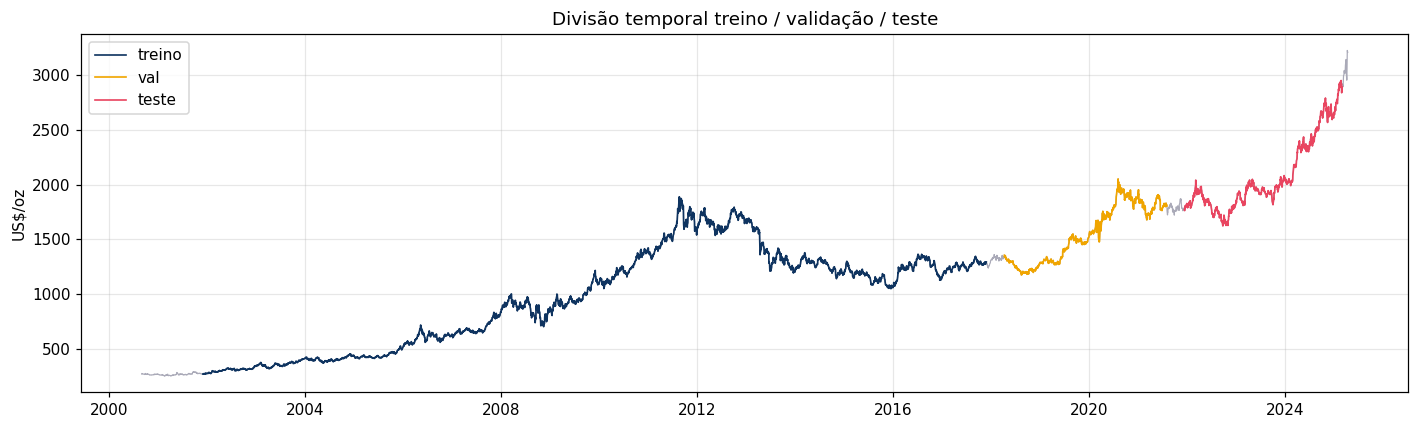

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df["date"], df["close"], color="#aaaab8", lw=0.8)
colors = {"treino": BLUE, "val": "#f0a500", "teste": RED}
for k, (X, Y, P, I) in data.items():
    seg = df.iloc[I[0] : I[-1] + 1]
    ax.plot(seg["date"], seg["close"], color=colors[k], lw=1.1, label=k)
ax.legend()
ax.set_title("Divisão temporal treino / validação / teste")
ax.set_ylabel("US$/oz")
plt.tight_layout()
plt.show()

## 4. Escalonamento robusto a outliers

`RobustScaler` usa **mediana/IQR** (não média/desvio), então as caudas pesadas das crises não distorcem a normalização. Ajustado **só no treino** (anti-vazamento) e seguido de um *clip* em ±8, que limita a influência de dias de pânico sem removê-los.

In [7]:
nf = data["treino"][0].shape[2]
x_scaler = RobustScaler().fit(data["treino"][0].reshape(-1, nf))


def scale_x(X):
    return np.clip(
        x_scaler.transform(X.reshape(-1, nf)).reshape(X.shape), -8, 8
    ).astype(np.float32)


y_scaler = RobustScaler().fit(data["treino"][1])


def to_dict(Ys):
    return {f"h{h}": Ys[:, j] for j, h in enumerate(HORIZONS)}


X = {k: scale_x(v[0]) for k, v in data.items()}
Yreal = {k: v[1] for k, v in data.items()}  # log-retorno real
Ys = {k: y_scaler.transform(v[1]).astype(np.float32) for k, v in data.items()}
Prices = {k: v[2] for k, v in data.items()}
Idx = {k: v[3] for k, v in data.items()}
print("escala aplicada — treino X:", X["treino"].shape)

escala aplicada — treino X: (4013, 60, 19)


## 5. Modelo CNN 1D causal

Convoluções **causais** (não olham o futuro dentro da janela) com **dilatação** 1→2→4 cobrem os 60 dias com poucas camadas. O *pooling* duplo (média + máximo) captura tendência **e** choques. Uma única rede com **três cabeças** prevê os três horizontes, compartilhando representação. Perda **Huber** = robusta a outliers.

In [8]:
def build_model(nf):
    inp = layers.Input(shape=(LOOKBACK, nf))
    x = layers.Conv1D(64, 5, padding="causal", activation="relu")(inp)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(64, 3, padding="causal", dilation_rate=2, activation="relu")(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, 3, padding="causal", dilation_rate=4, activation="relu")(x)
    x = layers.LayerNormalization()(x)
    x = layers.SpatialDropout1D(0.15)(x)
    x = layers.Concatenate()(
        [layers.GlobalAveragePooling1D()(x), layers.GlobalMaxPooling1D()(x)]
    )
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outs = [layers.Dense(1, name=f"h{h}")(x) for h in HORIZONS]
    m = Model(inp, outs)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss={f"h{h}": tf.keras.losses.Huber(1.0) for h in HORIZONS},
        loss_weights={"h5": 1.0, "h15": 0.7, "h30": 0.5},
    )
    return m


model = build_model(nf)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 60, 19)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 60, 64)    │      6,144 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 60, 64)    │        128 │ conv1d[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 60, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 64)    │        128 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 60, 128)   │     24,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 128)   │        256 │ conv1d_2[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 60, 128)   │          0 │ layer_normalizat… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ spatial_dropout1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ spatial_dropout1… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h5 (Dense)          │ (None, 1)         │         65 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h15 (Dense)         │ (None, 1)         │         65 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ h30 (Dense)         │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 60,355 (235.76 KB)

 Trainable params: 60,355 (235.76 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Treino e curvas de aprendizado

`EarlyStopping` restaura os melhores pesos; `ReduceLROnPlateau` corta a taxa de aprendizado quando a validação estaciona.

In [9]:
hist = model.fit(
    X["treino"],
    to_dict(Ys["treino"]),
    validation_data=(X["val"], to_dict(Ys["val"])),
    epochs=120,
    batch_size=64,
    verbose=0,
    callbacks=[
        callbacks.EarlyStopping(
            monitor="val_loss", patience=15, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5
        ),
    ],
)
print(f"Treinou {len(hist.history['loss'])} épocas")

Treinou 16 épocas


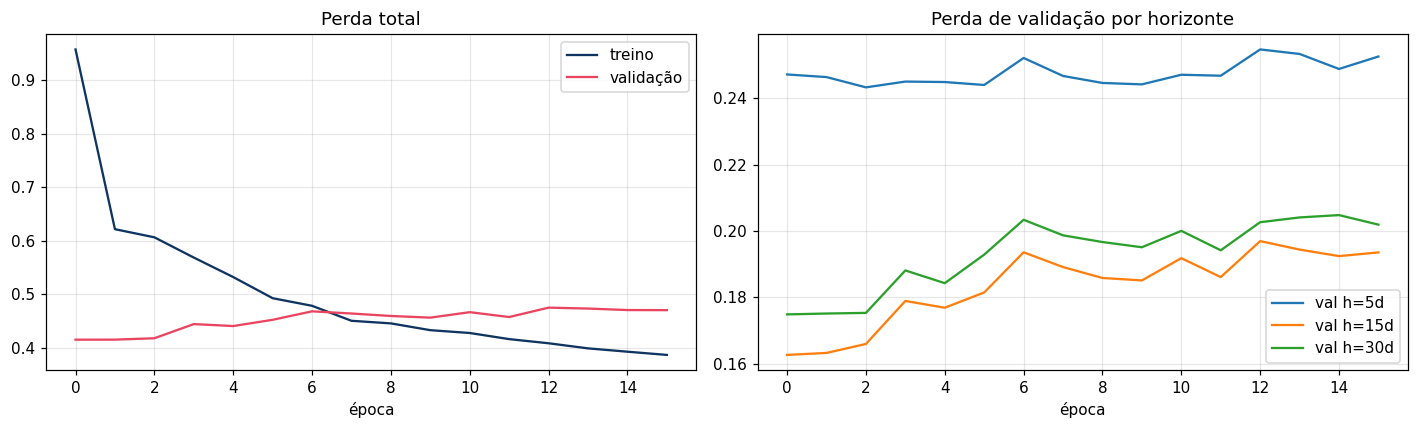

In [10]:
h = hist.history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h["loss"], label="treino", color=BLUE)
axes[0].plot(h["val_loss"], label="validação", color=RED)
axes[0].set_title("Perda total")
axes[0].set_xlabel("época")
axes[0].legend()
for hzn in HORIZONS:
    axes[1].plot(h[f"val_h{hzn}_loss"], label=f"val h={hzn}d")
axes[1].set_title("Perda de validação por horizonte")
axes[1].set_xlabel("época")
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Avaliação: treino / val / teste vs. baseline

Reconstruímos o **preço** a partir do retorno previsto e comparamos com o **random walk** (prever que o preço não muda). Se `MAE/naive < 1`, o modelo agrega valor. Também medimos a **acurácia direcional** (acertou se sobe ou desce).

In [11]:
def predict_returns(Xset):
    preds = model.predict(Xset, verbose=0)
    return y_scaler.inverse_transform(np.hstack(preds))  # (n,3) log-retornos


def metrics(split):
    pr = predict_returns(X[split])
    P = Prices[split]
    Yr = Yreal[split]
    rows = []
    for j, hzn in enumerate(HORIZONS):
        p_true = P * np.exp(Yr[:, j])
        p_pred = P * np.exp(pr[:, j])
        mae = np.mean(np.abs(p_true - p_pred))
        mae_naive = np.mean(np.abs(p_true - P))
        rmse = np.sqrt(np.mean((p_true - p_pred) ** 2))
        mape = np.mean(np.abs((p_true - p_pred) / p_true)) * 100
        dacc = np.mean(np.sign(pr[:, j]) == np.sign(Yr[:, j])) * 100
        rows.append(
            {
                "split": split,
                "h": hzn,
                "MAE": mae,
                "RMSE": rmse,
                "MAPE%": mape,
                "DirAcc%": dacc,
                "MAE/naive": mae / mae_naive,
            }
        )
    return pd.DataFrame(rows)


tbl = pd.concat([metrics(s) for s in ["treino", "val", "teste"]], ignore_index=True)
tbl.round(3)

,split,h,MAE,RMSE,MAPE%,DirAcc%,MAE/naive
0,treino,5,18.782,27.281,1.948,55.096,0.997
1,treino,15,32.821,46.621,3.371,56.691,0.998
2,treino,30,45.250,63.464,4.596,57.787,1.004
3,val,5,24.304,36.132,1.517,57.109,0.988
4,val,15,40.705,55.326,2.539,53.047,1.005
5,val,30,59.725,74.008,3.734,53.883,1.017
6,teste,5,32.416,41.483,1.560,56.506,0.983
7,teste,15,58.099,72.675,2.778,58.860,0.971
8,teste,30,83.134,101.481,3.890,61.958,0.950


In [12]:
# Tabela só do teste, formatada
t = tbl[tbl.split == "teste"].set_index("h")[
    ["MAE", "RMSE", "MAPE%", "DirAcc%", "MAE/naive"]
]
print("DESEMPENHO NO TESTE")
print(t.round(2).to_string())
print("\nMAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção")

DESEMPENHO NO TESTE
      MAE    RMSE  MAPE%  DirAcc%  MAE/naive
h                                           
5   32.42   41.48   1.56    56.51       0.98
15  58.10   72.67   2.78    58.86       0.97
30  83.13  101.48   3.89    61.96       0.95

MAE/naive < 1 => melhor que o baseline | DirAcc > 50% => acerta direção


## 8. Gráficos de desempenho

### 8.1 Previsto × Real no conjunto de teste
A linha vermelha (previsto) acompanha a preta (real). O modelo tende a ser **conservador** nos extremos — consequência da perda robusta.

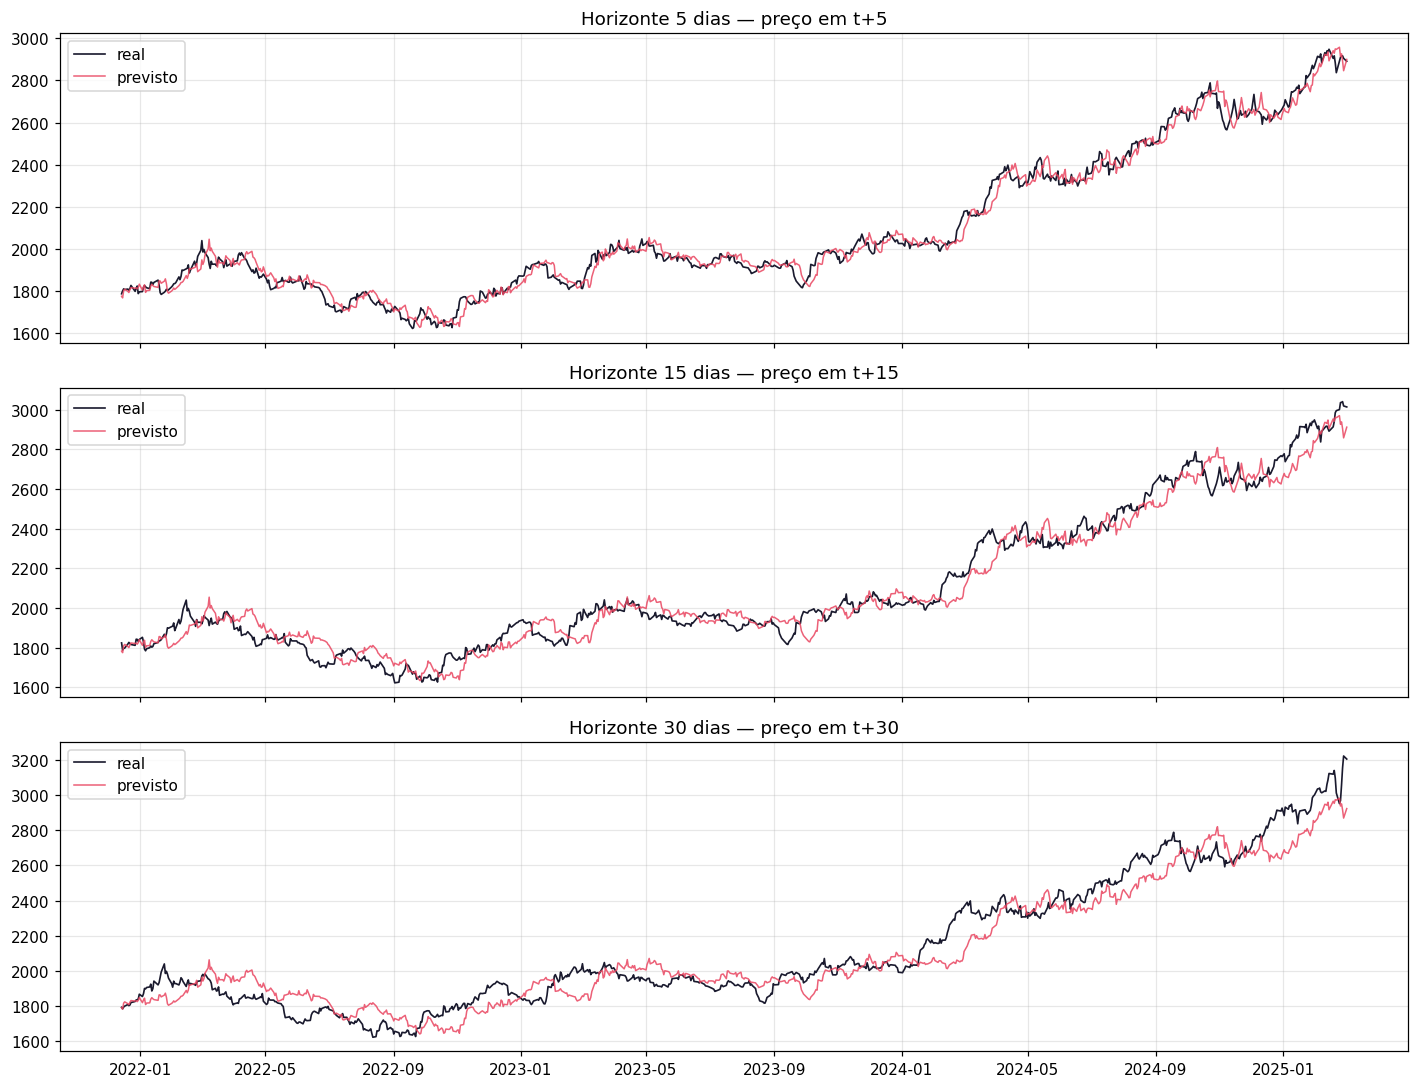

In [13]:
pr_te = predict_returns(X["teste"])
P_te = Prices["teste"]
dates_te = df["date"].values[Idx["teste"]]
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, j, hzn in zip(axes, range(3), HORIZONS):
    ax.plot(
        dates_te, P_te * np.exp(Yreal["teste"][:, j]), color=DARK, lw=1.1, label="real"
    )
    ax.plot(
        dates_te,
        P_te * np.exp(pr_te[:, j]),
        color=RED,
        lw=1.0,
        alpha=0.85,
        label="previsto",
    )
    ax.set_title(f"Horizonte {hzn} dias — preço em t+{hzn}")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 8.2 Dispersão previsto × real
Quanto mais perto da diagonal, melhor. `R²` resume o ajuste.

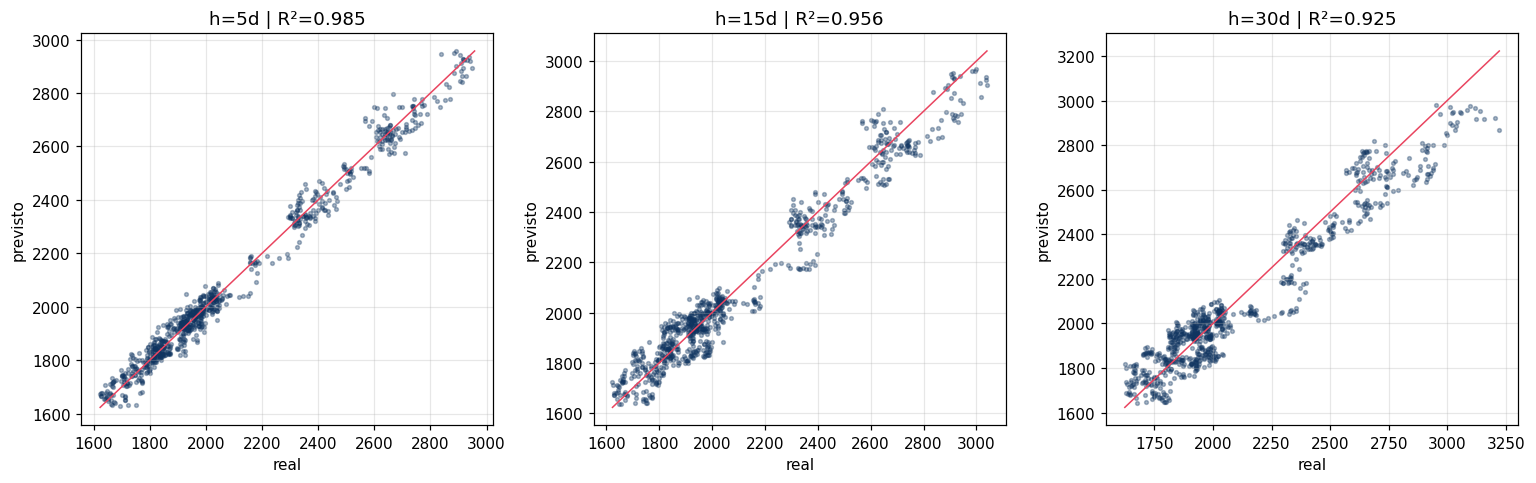

In [14]:
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, j, hzn in zip(axes, range(3), HORIZONS):
    yt = P_te * np.exp(Yreal["teste"][:, j])
    yp = P_te * np.exp(pr_te[:, j])
    ax.scatter(yt, yp, s=6, alpha=0.35, color=BLUE)
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], color=RED, lw=1)
    ax.set_title(f"h={hzn}d | R²={r2_score(yt, yp):.3f}")
    ax.set_xlabel("real")
    ax.set_ylabel("previsto")
plt.tight_layout()
plt.show()

### 8.3 Acurácia direcional e MAE/naive por ano (h=30)
Revela a **dependência de regime**: o modelo brilha em anos de tendência e empata com o baseline em mercado lateral.

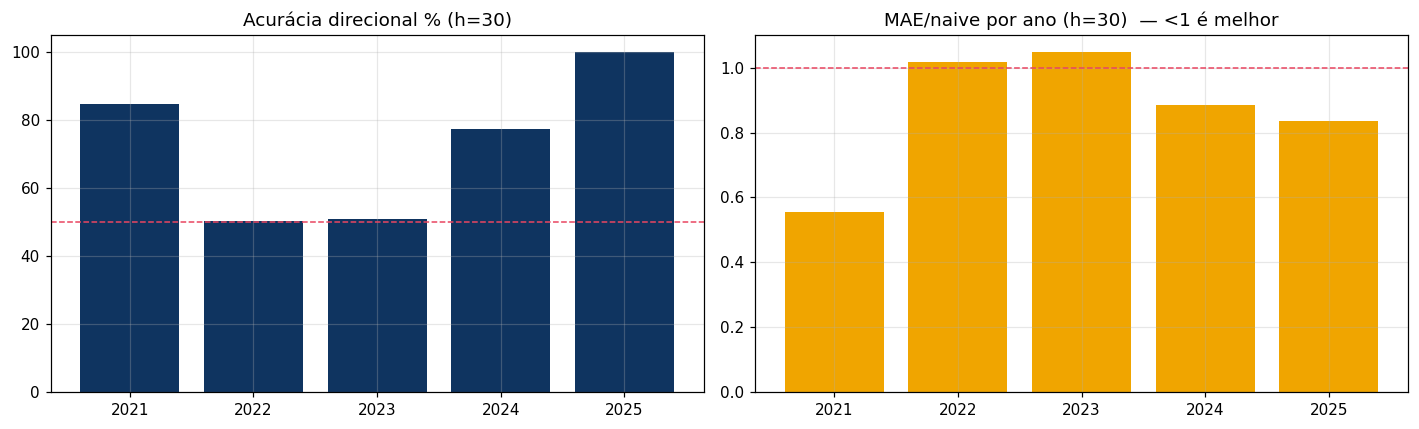

In [15]:
j = HORIZONS.index(30)
res = pd.DataFrame(
    {
        "ano": pd.to_datetime(dates_te).year,
        "dir_ok": np.sign(pr_te[:, j]) == np.sign(Yreal["teste"][:, j]),
        "ae": np.abs(P_te * np.exp(Yreal["teste"][:, j]) - P_te * np.exp(pr_te[:, j])),
        "ae_naive": np.abs(P_te * np.exp(Yreal["teste"][:, j]) - P_te),
    }
)
g = (
    res.groupby("ano")
    .agg(DirAcc=("dir_ok", "mean"), ratio=("ae", "sum"))
    .join(res.groupby("ano")["ae_naive"].sum().rename("naive_sum"))
)
g["ratio"] = g["ratio"] / g["naive_sum"]
g["DirAcc"] *= 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(g.index.astype(str), g["DirAcc"], color=BLUE)
axes[0].axhline(50, color=RED, ls="--", lw=1)
axes[0].set_title("Acurácia direcional % (h=30)")
axes[1].bar(g.index.astype(str), g["ratio"], color="#f0a500")
axes[1].axhline(1, color=RED, ls="--", lw=1)
axes[1].set_title("MAE/naive por ano (h=30)  — <1 é melhor")
plt.tight_layout()
plt.show()

### 8.4 Distribuição dos resíduos (h=30)
Centrado em zero indica baixo viés; caudas largas mostram os choques que o modelo não antecipa.

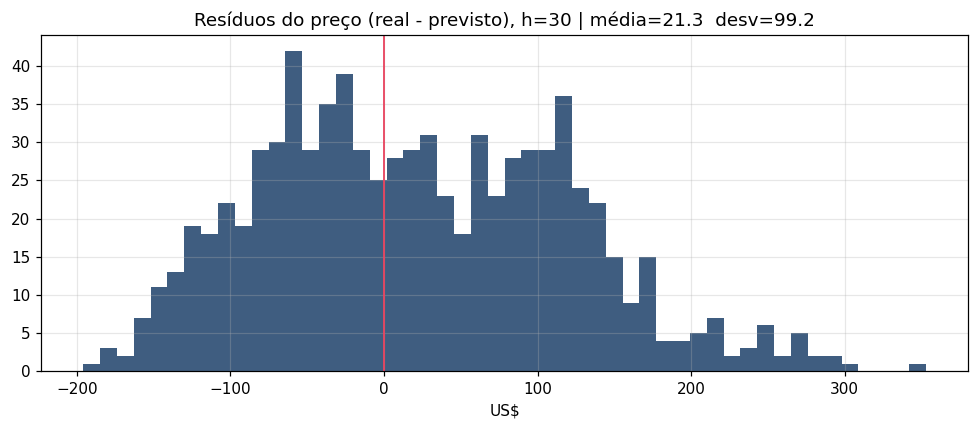

In [16]:
resid = (P_te * np.exp(Yreal["teste"][:, j])) - (P_te * np.exp(pr_te[:, j]))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(resid, bins=50, color=BLUE, alpha=0.8)
ax.axvline(0, color=RED, lw=1.2)
ax.set_title(
    f"Resíduos do preço (real - previsto), h=30 | média={resid.mean():.1f}  desv={resid.std():.1f}"
)
ax.set_xlabel("US$")
plt.tight_layout()
plt.show()

## Conclusão

- O alvo em **log-retorno** + features relativas resolve a não-estacionariedade do preço.
- O **split temporal com gap** e o `RobustScaler` ajustado só no treino evitam vazamento e domesticam outliers de crise.
- O modelo **bate o baseline** nos três horizontes no teste, com acurácia direcional crescente no horizonte — mas o desempenho **depende do regime** (forte em tendência, neutro em mercado lateral), como mostram os gráficos por ano.
- Expectativa realista: acurácia direcional na casa dos 55% é um bom resultado para preço de ouro; números muito acima disso costumam indicar vazamento.

**Próximos passos:** walk-forward com retreino periódico, predição por quantis (bandas de incerteza) e features exógenas (DXY, juro real, prata). Para uso real, isto é material de estudo e gestão de risco — não recomendação de investimento.